In [1]:
import pandas as pd
import glob

# Find the Excel file automatically (name is long, this avoids typos)
excel_file = glob.glob("tmdb_movies_2024_*.xlsx")[0]
print(f"Loading: {excel_file}")

df = pd.read_excel(excel_file)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loading: tmdb_movies_2024_2026.xlsx
Loaded 131,110 rows and 30 columns


,id,title,original_title,release_date,status,runtime_minutes,genres,overview,tagline,vote_average,...,producers,top_10_cast,full_cast,keywords,homepage,imdb_id,poster_url,backdrop_url,adult,belongs_to_collection
0,5492,Gunner,Gunner,2024-08-16,Released,90,"Action, Thriller, Crime","While on a camping trip in order to reconnect,...",Vengeance has a new name.,5.275,...,"Joel Shapiro, Dimitri Logothetis","Luke Hemsworth, Morgan Freeman, Joseph Baena, ...","Luke Hemsworth, Morgan Freeman, Joseph Baena, ...","race against time, rescue mission, family in d...",NaN,tt12598606,https://image.tmdb.org/t/p/original/cS2TXN1Ylr...,https://image.tmdb.org/t/p/original/bxwKC4qAbc...,False,NaN
1,7181,Dusk,Dusk,2026-03-07,Released,99,Horror,When a series of unexplained events begin to e...,NaN,0.000,...,"Greg Wylie, Kyle Hodgkinson","Laura Bailey, Bruce Dubose, Todd Haberkorn, Gi...","Laura Bailey, Bruce Dubose, Todd Haberkorn, Gi...","isolation, obsession, paranoia, supernatural, ...",http://www.duskthemovie.com/Home.html,tt1094588,https://image.tmdb.org/t/p/original/e2tWEpDPxy...,NaN,False,NaN
2,13494,Red Sonja,Red Sonja,2025-07-31,Released,111,"Adventure, Action, Fantasy, Drama",A young girl rises from the ashes of tragedy t...,A hero will rise... An empire will fall.,5.676,...,"Mark Canton, Courtney Solomon, Christa Campbel...","Matilda Lutz, Robert Sheehan, Wallis Day, Luke...","Matilda Lutz, Robert Sheehan, Wallis Day, Luke...","monster, swordplay, villainess, queen, talisma...",http://www.samuelgoldwynfilms.com/red-sonja,tt0800175,https://image.tmdb.org/t/p/original/aE3yh4y0h9...,https://image.tmdb.org/t/p/original/xSD0q1FiuZ...,False,NaN
3,43972,The Sealed Soil,خاک سر به مهر,2025-05-30,Released,90,Drama,A young woman in pre-revolution Iran is caught...,NaN,8.000,...,Marva Nabili,Flora Shabaviz,Flora Shabaviz,woman director,NaN,tt0154728,https://image.tmdb.org/t/p/original/9klV30BhcR...,https://image.tmdb.org/t/p/original/ujfwhirdCA...,False,NaN
4,67300,Castle Orgies,色暦大奥秘話,2026-06-22,Released,68,Drama,A young girl who has been made a maidservant i...,NaN,0.000,...,Akira Miura,"Setsuko Ogawa, Yoichi Nishikawa, Yasuko Matsui...","Setsuko Ogawa, Yoichi Nishikawa, Yasuko Matsui...",pink film,https://www.nikkatsu-romanporno.com/movies/201...,tt0212841,https://image.tmdb.org/t/p/original/1M1S8fbgDZ...,https://image.tmdb.org/t/p/original/n9ENwA881b...,False,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131110 entries, 0 to 131109
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     131110 non-null  int64  
 1   title                  131102 non-null  object 
 2   original_title         131103 non-null  object 
 3   release_date           131107 non-null  object 
 4   status                 131110 non-null  object 
 5   runtime_minutes        131110 non-null  int64  
 6   genres                 105007 non-null  object 
 7   overview               109265 non-null  object 
 8   tagline                29366 non-null   object 
 9   vote_average           131110 non-null  float64
 10  vote_count             131110 non-null  int64  
 11  popularity             131110 non-null  float64
 12  budget                 131110 non-null  int64  
 13  revenue                131110 non-null  int64  
 14  original_language      131110 non-nu

In [3]:
df.columns

Index(['id', 'title', 'original_title', 'release_date', 'status',
       'runtime_minutes', 'genres', 'overview', 'tagline', 'vote_average',
       'vote_count', 'popularity', 'budget', 'revenue', 'original_language',
       'spoken_languages', 'production_companies', 'production_countries',
       'director', 'writers', 'producers', 'top_10_cast', 'full_cast',
       'keywords', 'homepage', 'imdb_id', 'poster_url', 'backdrop_url',
       'adult', 'belongs_to_collection'],
      dtype='object')

In [4]:
df["ROI"] = (df["revenue"] - df["budget"]) / df["budget"]
df[["revenue", "budget", "ROI"]].head()

,revenue,budget,ROI
0,0,20000000,-1.0
1,0,0,NaN
2,271461,0,inf
3,0,0,NaN
4,0,0,NaN


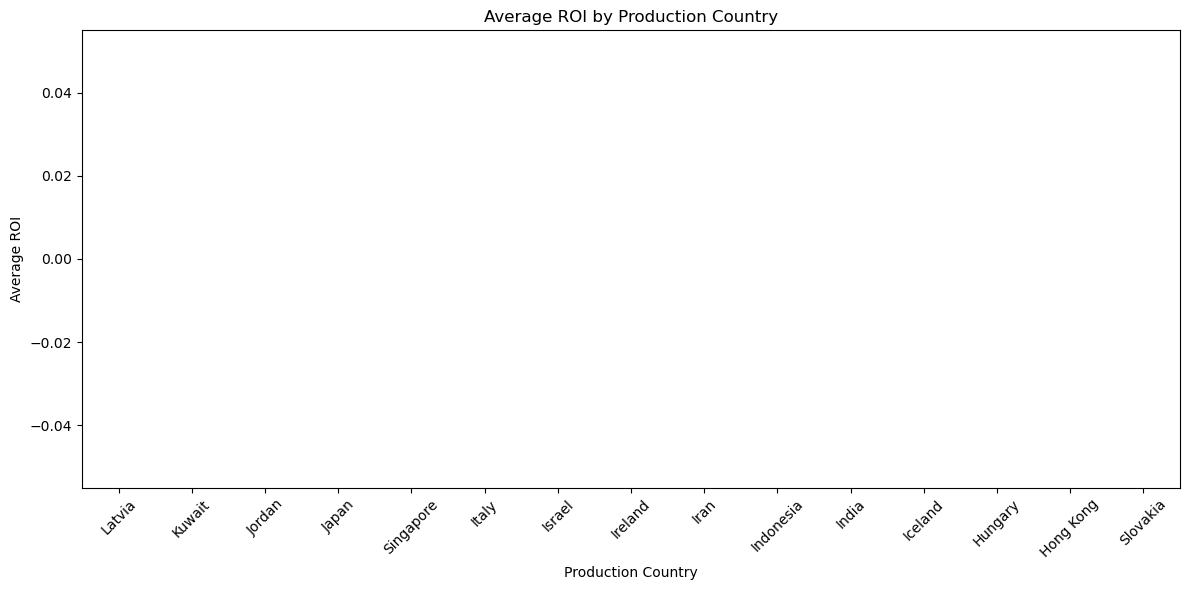

prod_country
Latvia       inf
Kuwait       inf
Jordan       inf
Japan        inf
Singapore    inf
Italy        inf
Israel       inf
Ireland      inf
Iran         inf
Indonesia    inf
India        inf
Iceland      inf
Hungary      inf
Hong Kong    inf
Slovakia     inf
Name: ROI, dtype: float64

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

if "ROI" not in df.columns:
    df["ROI"] = np.where(
        df["budget"].ne(0),
        (df["revenue"] - df["budget"]) / df["budget"],
        np.nan,
    )

country_roi = (
    df.assign(prod_country=df["production_countries"].fillna("").str.split(","))
    .explode("prod_country")
    .assign(prod_country=lambda x: x["prod_country"].str.strip())
    .loc[lambda x: x["prod_country"].ne("")]
    [["prod_country", "ROI"]]
)

avg_roi_by_country = (
    country_roi.groupby("prod_country")["ROI"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

top_countries = avg_roi_by_country.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average ROI by Production Country")
ax.set_xlabel("Production Country")
ax.set_ylabel("Average ROI")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

top_countries

Highest percentage genre: Drama (22.51%)
Lowest percentage genre: Western (0.32%)


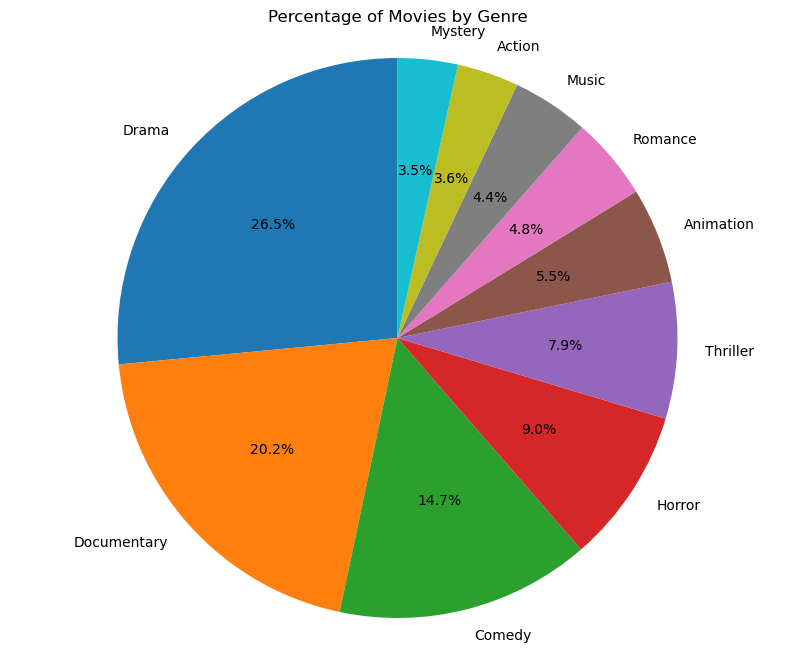

genres
Drama          22.505710
Documentary    17.136675
Comedy         12.471451
Horror          7.618704
Thriller        6.685900
Animation       4.697079
Romance         4.053973
Music           3.769684
Action          3.026806
Mystery         2.941459
Name: count, dtype: float64

In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# Explode the comma-separated genres into one row per genre
genre_series = (
    df["genres"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .loc[lambda s: s != ""]
)

# Count each genre and convert to percentages
genre_counts = genre_series.value_counts()
genre_pct = genre_counts / genre_counts.sum() * 100

# Show max and min genres
max_genre = genre_pct.idxmax()
min_genre = genre_pct.idxmin()
max_pct = genre_pct.max()
min_pct = genre_pct.min()

print(f"Highest percentage genre: {max_genre} ({max_pct:.2f}%)")
print(f"Lowest percentage genre: {min_genre} ({min_pct:.2f}%)")

# Plot pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    genre_pct.head(10).values,
    labels=genre_pct.head(10).index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.6,
)
plt.title("Percentage of Movies by Genre")
plt.axis("equal")
plt.show()

genre_pct.head(10)

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Budget-controlled hypothesis test:
# H0: controlling for budget, franchise status has no relationship with revenue
# H1: franchise films out-earn budget-matched standalone films

sub = df[['budget', 'revenue', 'belongs_to_collection']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)].copy()

# 1 = belongs to a collection; 0 = standalone
sub['franchise'] = sub['belongs_to_collection'].notna().astype(int)
sub['log_budget'] = np.log1p(sub['budget'])
sub['log_revenue'] = np.log1p(sub['revenue'])

X = sm.add_constant(sub[['log_budget', 'franchise']])
y = sub['log_revenue']
model = sm.OLS(y, X).fit()

print('rows_used =', len(sub))
print('budget_coef =', model.params['log_budget'])
print('franchise_coef =', model.params['franchise'])
print('franchise_p_value =', model.pvalues['franchise'])
print('r_squared =', model.rsquared)

# Approximate multiplicative premium from regression coefficient
prem = (np.exp(model.params['franchise']) - 1) * 100
print('approx_revenue_premium_percent =', round(prem, 4))

model.summary()

rows_used = 2059
slope = 0.9360941178412436
intercept = 0.40265398711025213
r = 0.9155748082891364
p_value = 0.0
stderr = 0.009065549257085163


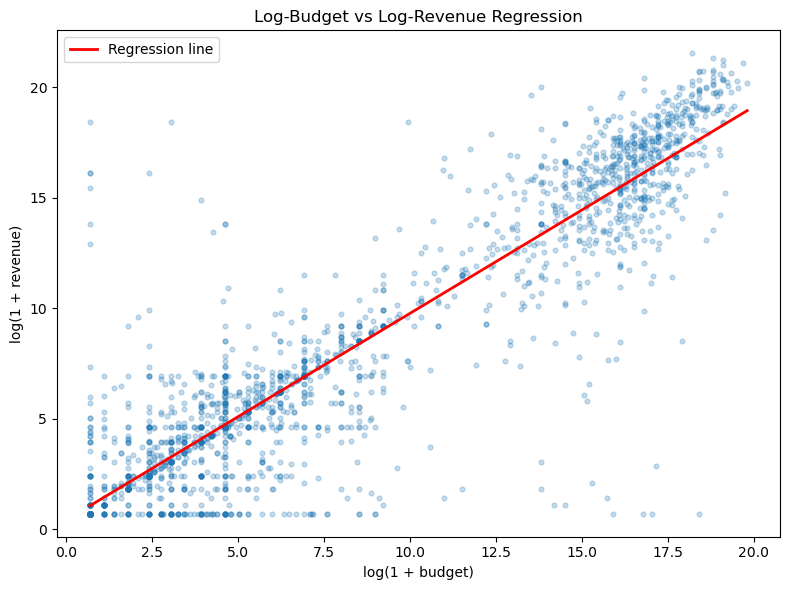

LinregressResult(slope=0.9360941178412436, intercept=0.40265398711025213, rvalue=0.9155748082891364, pvalue=0.0, stderr=0.009065549257085163, intercept_stderr=0.09505150057803703)

In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Filter to positive, interpretable records
sub = df[['budget', 'revenue']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)]

x = np.log1p(sub['budget'])
y = np.log1p(sub['revenue'])

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

# Scatter plot with fitted regression line
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.25, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Log-Budget vs Log-Revenue Regression')
plt.xlabel('log(1 + budget)')
plt.ylabel('log(1 + revenue)')
plt.legend()
plt.tight_layout()
plt.show()

res

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm

sub = df[['budget', 'revenue', 'belongs_to_collection']].copy().dropna()
sub = sub[(sub['budget'] > 0) & (sub['revenue'] > 0)].copy()

sub['franchise'] = sub['belongs_to_collection'].notna().astype(int)
sub['log_budget'] = np.log1p(sub['budget'])
sub['log_revenue'] = np.log1p(sub['revenue'])

X = sm.add_constant(sub[['log_budget', 'franchise']])
y = sub['log_revenue']
model = sm.OLS(y, X).fit()

print('rows_used =', len(sub))
print('budget_coef =', model.params['log_budget'])
print('franchise_coef =', model.params['franchise'])
print('franchise_p_value =', model.pvalues['franchise'])
print('r_squared =', model.rsquared)

prem = (np.exp(model.params['franchise']) - 1) * 100
print('approx_revenue_premium_percent =', round(prem, 4))

model.summary()

rows_used = 147
budget_coef = 1.0108487754143634
franchise_coef = 0.7479182667737767
franchise_p_value = 0.32630807431197373
r_squared = 0.7749244993343377
approx_revenue_premium_percent = 111.2598


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     499.2
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           8.30e-49
Time:                        20:40:47   Log-Likelihood:                -281.69
No. Observations:                 147   AIC:                             567.4
Df Residuals:                     145   BIC:                             573.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
log_budget     1.0108      0.045     22.343      0.000       0.921       1.100
franchise      0.7479      0.759      0.985      0.326      -0.753       2.249
==============================================================================
Omnibus:                       18.172   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.472
Skew:                          -0.534   Prob(JB):                     1.20e-08
Kurtosis:                       5.194   Cond. No.                         93.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

rows_used = 2600
slope = 0.07893008376483276
intercept = 4.6314469695686284
r = 0.7315991317269441
p_value = 0.0
stderr = 0.0014429970620253776


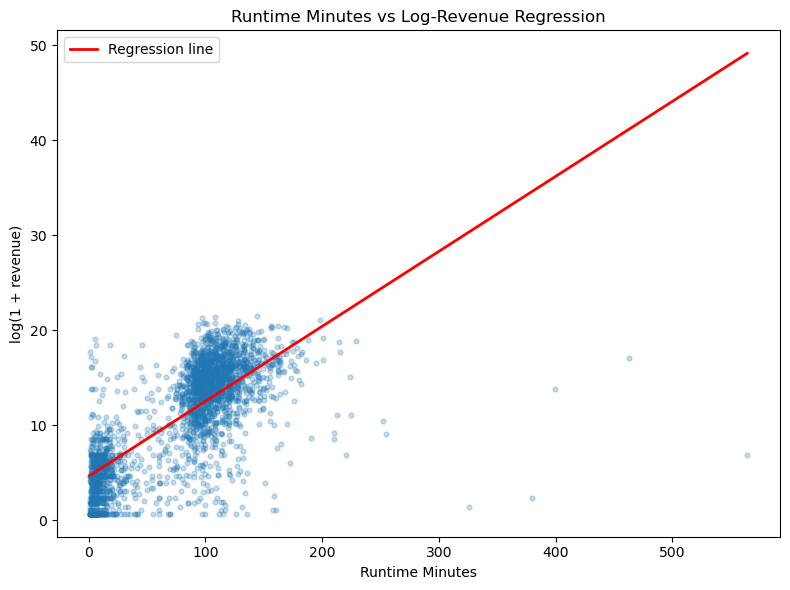

LinregressResult(slope=0.07893008376483276, intercept=4.6314469695686284, rvalue=0.7315991317269441, pvalue=0.0, stderr=0.0014429970620253776, intercept_stderr=0.1361422242059603)

In [11]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Regression test: runtime_minutes -> revenue
sub = df[['runtime_minutes', 'revenue']].copy().dropna()
sub = sub[(sub['runtime_minutes'] > 0) & (sub['revenue'] > 0)]

x = sub['runtime_minutes']
y = np.log1p(sub['revenue'])

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.25, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Runtime Minutes vs Log-Revenue Regression')
plt.xlabel('Runtime Minutes')
plt.ylabel('log(1 + revenue)')
plt.legend()
plt.tight_layout()
plt.show()

res

In [13]:
%matplotlib inline
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Parse genres and create one row per genre per movie
rows = []
for _, row in df[['genres', 'revenue']].iterrows():
    genres = [g.strip() for g in str(row['genres']).split(',') if g.strip()]
    for genre in genres:
        rows.append({'genre': genre, 'revenue': row['revenue']})

genre_df = pd.DataFrame(rows)

# Keep only positive revenue values and use log-transform for a more stable ANOVA
genre_df = genre_df[genre_df['revenue'] > 0].copy()
genre_df['log_revenue'] = np.log1p(genre_df['revenue'])

# Limit to genres with enough observations
valid = genre_df.groupby('genre').filter(lambda x: len(x) >= 50)

# Overall ANOVA
samples = [group['log_revenue'].values for _, group in valid.groupby('genre')]
f_stat, p_value = stats.f_oneway(*samples)

print('Overall ANOVA')
print('genres_used =', len(valid['genre'].unique()))
print('f_stat =', f_stat)
print('p_value =', p_value)
print('\nMean revenue by genre:')
print(valid.groupby('genre')['revenue'].mean().sort_values(ascending=False).head(10))

# Post-hoc Tukey HSD test
label = valid['genre']
value = valid['log_revenue']

posthoc = pairwise_tukeyhsd(endog=value, groups=label, alpha=0.05)
print('\nTukey HSD post-hoc results:')
print(posthoc)


Overall ANOVA
genres_used = 18
f_stat = 29.44498330168375
p_value = 6.166686311514743e-92

Mean revenue by genre:
genre
Adventure          9.889961e+07
Science Fiction    7.701837e+07
Animation          6.915401e+07
Family             6.689265e+07
Fantasy            6.671380e+07
Action             5.415685e+07
Comedy             2.819574e+07
War                2.716226e+07
Crime              2.231926e+07
Mystery            2.158772e+07
Name: revenue, dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,



Tukey HSD post-hoc results:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
         Action       Adventure  -0.0129    1.0 -1.5466  1.5208  False
         Action       Animation  -0.0493    1.0 -1.6545  1.5559  False
         Action          Comedy   -2.109    0.0  -3.253  -0.965   True
         Action           Crime  -1.0829 0.5209 -2.5873  0.4215  False
         Action     Documentary  -5.4374    0.0 -6.8587 -4.0161   True
         Action           Drama   -2.599    0.0 -3.6794 -1.5186   True
         Action          Family  -0.4539 0.9999 -2.0202  1.1125  False
         Action         Fantasy   -0.632 0.9968 -2.2466  0.9825  False
         Action         History  -0.2197    1.0 -2.1003  1.6609  False
         Action          Horror  -3.3399    0.0 -4.6302 -2.0495   True
         Action           Music    -2.23 0.0011 

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Hypothesis test: popularity -> vote_average
sub = df[['popularity', 'vote_average']].copy().dropna()
sub = sub[(sub['popularity'] > 0) & (sub['vote_average'] > 0)].copy()

x = np.log1p(sub['popularity'])
y = sub['vote_average']

res = stats.linregress(x, y)
print('rows_used =', len(sub))
print('slope =', res.slope)
print('intercept =', res.intercept)
print('r =', res.rvalue)
print('p_value =', res.pvalue)
print('stderr =', res.stderr)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2, s=12)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = res.intercept + res.slope * x_fit
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Regression line')

plt.title('Popularity vs Vote Average Regression')
plt.xlabel('log(1 + popularity)')
plt.ylabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.show()

res